### Author : Riasad Alvi
### Date   : 27 Feb 2025

In [1]:
import numpy as np  # Import NumPy for numerical operations
import pandas as pd  # Import pandas for data manipulation and analysis
import os  # Import OS module to interact with the file system
import matplotlib.pyplot as plt  # Import Matplotlib for data visualization
import seaborn as sns  # Import Seaborn for statistical data visualization
import warnings  # Import warnings module to manage warning messages
from tqdm.notebook import tqdm  # Import tqdm for progress bars in Jupyter Notebook

# Ignore warnings to keep the output clean
warnings.filterwarnings('ignore')

# Enable inline plotting for Jupyter Notebook
%matplotlib inline

# Import TensorFlow and Keras modules for deep learning
import tensorflow as tf  # Import TensorFlow framework

# Import functions for image preprocessing from Keras
from keras.preprocessing.image import load_img  # Load images for processing

# Import Keras model-building utilities
from keras.models import Sequential, Model  # 'Sequential' for linear model building, 'Model' for functional API

# Import various Keras layers
from keras.layers import Dense, Conv2D, Dropout, Flatten, MaxPooling2D, Input  
# Dense - Fully connected layer
# Conv2D - Convolutional layer for feature extraction
# Dropout - Regularization to prevent overfitting
# Flatten - Convert multi-dimensional input to 1D
# MaxPooling2D - Downsample feature maps to reduce dimensions
# Input - Define input layer shape


### Load Dataset : 

In [2]:
BASE_DIR='/kaggle/input/utkface-new/UTKFace'


In [3]:

# Labels: Age, Gender, Ethnicity

images_paths = []  # List to store image file paths
age_labels = []  # List to store age labels
gender_labels = []  # List to store gender labels

# Loop through all files in the directory
for filename in tqdm(os.listdir(BASE_DIR)):  
    image_path = os.path.join(BASE_DIR, filename)  # Get full path of the image
    
    temp = filename.split('_')  # Split filename based on '_'
    
    age = int(temp[0])  # Extract age (first value in filename)
    gender = int(temp[1])  # Extract gender (second value in filename)
    
    images_paths.append(image_path)  # Store image path
    age_labels.append(age)  # Store age label
    gender_labels.append(gender)  # Store gender label


  0%|          | 0/23708 [00:00<?, ?it/s]

In [4]:
import pandas as pd  # Import pandas for data manipulation

# Create an empty DataFrame
df = pd.DataFrame()

# Assign extracted data to DataFrame columns
df['image'] = images_paths  # Column for image file paths
df['age'] = age_labels  # Column for age labels
df['gender'] = gender_labels  # Column for gender labels

# Display the first few rows of the DataFrame
df.head()

,image,age,gender
0,/kaggle/input/utkface-new/UTKFace/26_0_2_20170...,26,0
1,/kaggle/input/utkface-new/UTKFace/22_1_1_20170...,22,1
2,/kaggle/input/utkface-new/UTKFace/21_1_3_20170...,21,1
3,/kaggle/input/utkface-new/UTKFace/28_0_0_20170...,28,0
4,/kaggle/input/utkface-new/UTKFace/17_1_4_20170...,17,1


In [5]:
# Define a dictionary to map gender labels
gender_dict = {0: 'Male', 1: 'Female'}  # 0 → Male, 1 → Female

### Exploratory Data Analysis : 

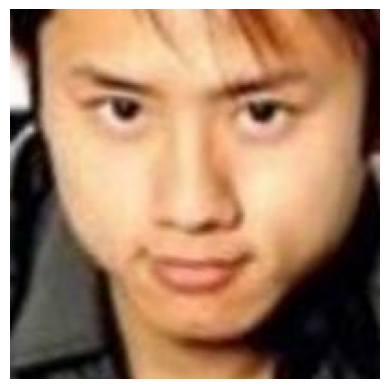

In [6]:
from PIL import Image  # Import PIL for image processing

# Open the first image from the DataFrame
img = Image.open(df['image'][0])  # Load image using its file path

# Hide axis for better visualization
plt.axis('off')  

# Display the image
plt.imshow(img);  


<Axes: xlabel='age', ylabel='Count'>

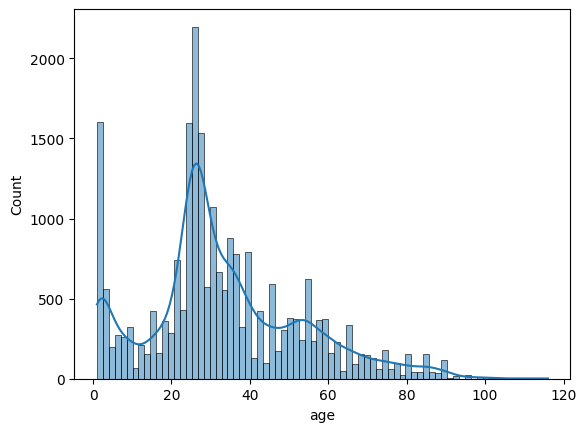

In [7]:
sns.histplot(df['age'], kde=True)  # Plots the distribution of the 'age' column using a histogram with a density curve


<Axes: xlabel='gender', ylabel='count'>

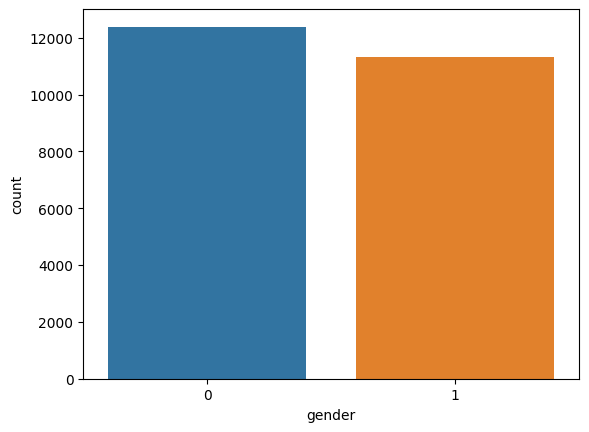

In [8]:
sns.countplot(x=df['gender']) # Plots the count of each unique value in the 'gender' column

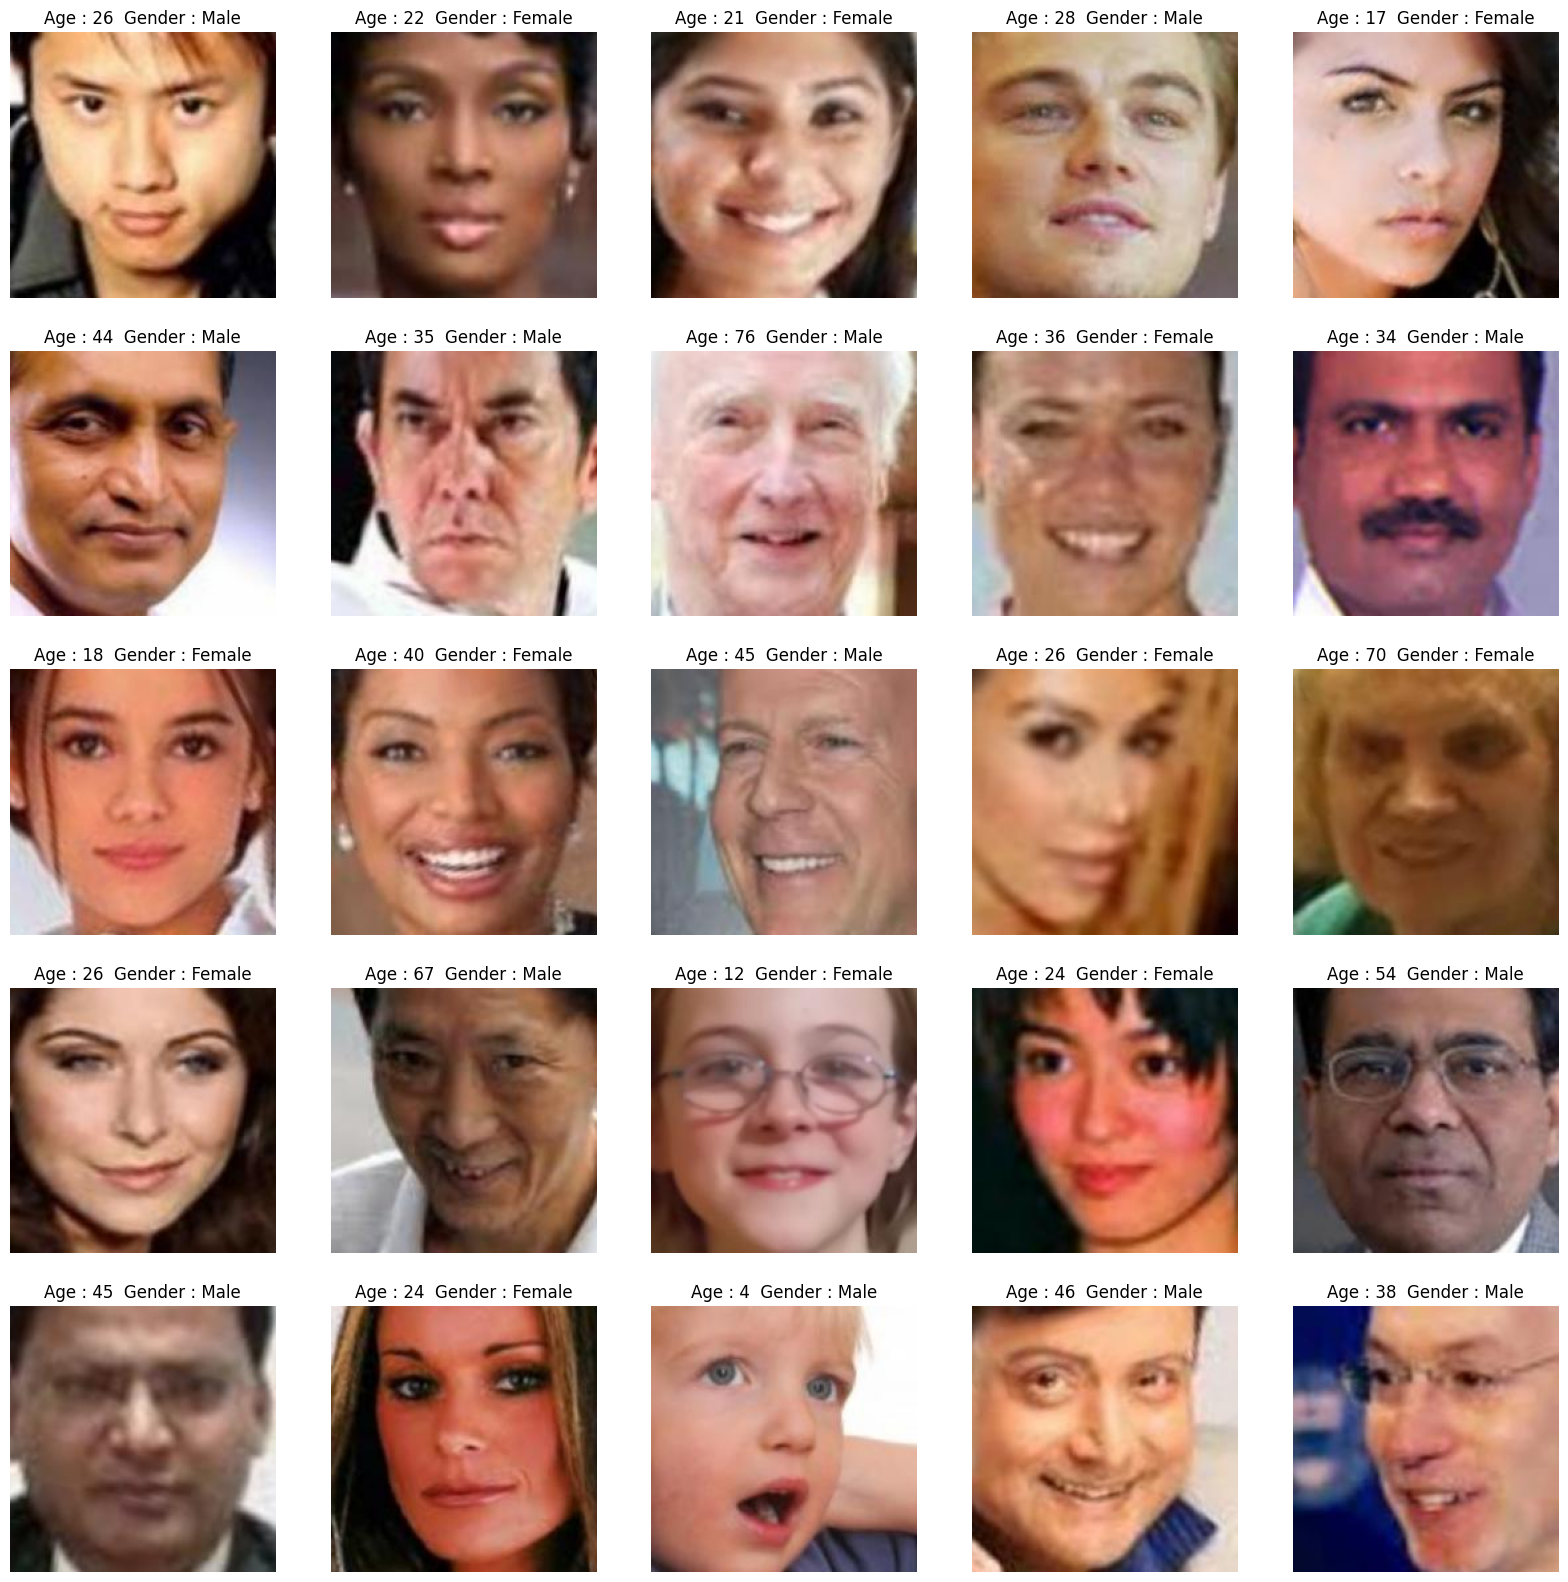

In [9]:
plt.figure(figsize=(20,20))  # Set the figure size to 20x20 inches
files = df.iloc[0:25]  # Select the first 25 rows from the DataFrame

# Loop through each file and its respective labels
for index, file, age, gender in files.itertuples():  
    plt.subplot(5,5,index+1)  # Create a 5x5 grid of subplots, index+1 for proper indexing
    img = load_img(file)  # Load the image from the file path
    img = np.array(img)  # Convert the image to a NumPy array
    plt.imshow(img)  # Display the image
    # Set the title with age and gender information
    plt.title(f'Age : {age}  Gender : {gender_dict[gender]}')  
    plt.axis('off')  # Turn off the axis for cleaner visualization


### Feature Extraction : 

In [10]:
def extract_features(images):  
    features = []  # Initialize an empty list to store extracted features
    
    for image in tqdm(images):  # Iterate through the list of image file paths with a progress bar
        img = load_img(image, color_mode='grayscale')  # Load the image in grayscale mode
        img = img.resize((128, 128))  # Resize the image to 128x128 pixels (no need for ANTIALIAS)
        img = np.array(img)  # Convert the image to a NumPy array
        features.append(img)  # Append the processed image to the features list

    features = np.array(features)  # Convert the list into a NumPy array

    # Ignore this step while using RGB images
    features = features.reshape(len(features), 128, 128, 1)  # Reshape for grayscale (single channel)

    return features  # Return the extracted features as a NumPy array


In [11]:
X = extract_features(df['image'])

  0%|          | 0/23708 [00:00<?, ?it/s]

In [16]:
X.shape

(23708, 128, 128, 1)

In [17]:
X = X / 255.0  # Normalize pixel values to the range [0,1] by dividing by 255


In [18]:
y_gender = np.array(df['gender'])  # Convert the 'gender' column from the DataFrame into a NumPy array
y_age = np.array(df['age'])  # Convert the 'age' column from the DataFrame into a NumPy array


In [15]:
input_shape = (128, 128, 1)  # Define the input shape for grayscale images (Height, Width, Channels)

### Model Creation : 

In [53]:
# Define the input layer with the given input shape
inputs = Input(shape=input_shape)  
# Convolutional layers with ReLU activation and max pooling
conv_1 = Conv2D(32, kernel_size=(3,3), activation='relu')(inputs)
maxp_1 = MaxPooling2D(pool_size=(2,2))(conv_1)
conv_2 = Conv2D(64, kernel_size=(3,3), activation='relu')(maxp_1)
maxp_2 = MaxPooling2D(pool_size=(2,2))(conv_2)
conv_3 = Conv2D(128, kernel_size=(3,3), activation='relu')(maxp_2)
maxp_3 = MaxPooling2D(pool_size=(2,2))(conv_3)
conv_4 = Conv2D(256, kernel_size=(3,3), activation='relu')(maxp_3)
maxp_4 = MaxPooling2D(pool_size=(2,2))(conv_4)

# Flatten the output from convolutional layers
flatten = Flatten()(maxp_4)

# Fully connected layers with ReLU activation - keep your structure
dense_1 = Dense(256, activation='relu')(flatten)
dense_2 = Dense(256, activation='relu')(flatten)

# Dropout layers to prevent overfitting
dropout_1 = Dropout(0.3)(dense_1)
dropout_2 = Dropout(0.3)(dense_2)  

# Output layers - change age output activation to linear
output_1 = Dense(1, activation='sigmoid', name='gender_out')(dropout_1)
output_2 = Dense(1, activation='linear', name='age_out')(dropout_2)  # Changed from 'relu' to 'linear'

# Define the model with two outputs
model = Model(inputs=[inputs], outputs=[output_1, output_2])

# Compile with loss weights to prevent one loss from dominating
from tensorflow.keras.optimizers import Adam
model.compile(
    loss={'gender_out': 'binary_crossentropy', 'age_out': 'mae'},
    loss_weights={'gender_out': 1.0, 'age_out': 0.01},  # Add weight to balance losses
    optimizer=Adam(learning_rate=0.001),
    metrics={'gender_out': ['accuracy'], 'age_out': ['mae']}
)

# Normalize age values before training
y_age_normalized = y_age / 100.0  # Scale ages to smaller values

# Train the model with the normalized age values
history = model.fit(
    x=X,
    y=[y_gender, y_age_normalized],  # Use normalized age values
    batch_size=32,
    epochs=10,
    validation_split=0.2
)

Epoch 1/10
593/593 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step - age_out_loss: 0.7129 - age_out_mae: 0.1722 - gender_out_accuracy: 0.5126 - gender_out_loss: 0.0049 - loss: 0.7179 - val_age_out_loss: 0.6370 - val_age_out_mae: 0.1574 - val_gender_out_accuracy: 0.5299 - val_gender_out_loss: 0.0047 - val_loss: 0.6415
Epoch 2/10
593/593 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - age_out_loss: 0.6404 - age_out_mae: 0.1576 - gender_out_accuracy: 0.5199 - gender_out_loss: 0.0048 - loss: 0.6452 - val_age_out_loss: 0.6359 - val_age_out_mae: 0.1539 - val_gender_out_accuracy: 0.5299 - val_gender_out_loss: 0.0047 - val_loss: 0.6404
Epoch 3/10
593/593 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - age_out_loss: 0.6375 - age_out_mae: 0.1546 - gender_out_accuracy: 0.5184 - gender_out_loss: 0.0048 - loss: 0.6423 - val_age_out_loss: 0.6346 - val_age_out_mae: 0.1573 - val_gender_out_accuracy: 0.5299 - val_gender_out_loss: 0.0047 - val_loss: 0.6391
Epoch 4/10
593/593 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - age_out_loss: 0.6320 - age_ou

In [54]:
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4             │ (None, 128, 128, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_8 (Conv2D)         │ (None, 126, 126, 32)   │            896 │ input_layer_4[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_8           │ (None, 63, 63, 32)     │              0 │ conv2d_8[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_9 (Conv2D)         │ (None, 61, 61, 64)     │         18,496 │ max_pooling2d_8[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_9           │ (None, 30, 30, 64)     │              0 │ conv2d_9[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_10 (Conv2D)        │ (None, 28, 28, 128)    │         73,856 │ max_pooling2d_9[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_10          │ (None, 14, 14, 128)    │              0 │ conv2d_10[0][0]        │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_11 (Conv2D)        │ (None, 12, 12, 256)    │        295,168 │ max_pooling2d_10[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_11          │ (None, 6, 6, 256)      │              0 │ conv2d_11[0][0]        │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten_2 (Flatten)       │ (None, 9216)           │              0 │ max_pooling2d_11[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_6 (Dense)           │ (None, 256)            │      2,359,552 │ flatten_2[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_7 (Dense)           │ (None, 256)            │      2,359,552 │ flatten_2[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_6 (Dropout)       │ (None, 256)            │              0 │ dense_6[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_7 (Dropout)       │ (None, 256)            │              0 │ dense_7[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ gender_out (Dense)        │ (None, 1)              │            257 │ dropout_6[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ age_out (Dense)           │ (None, 1)              │            257 │ dropout_7[0][0]        │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 15,324,104 (58.46 MB)

 Trainable params: 5,108,034 (19.49 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 10,216,070 (38.97 MB)

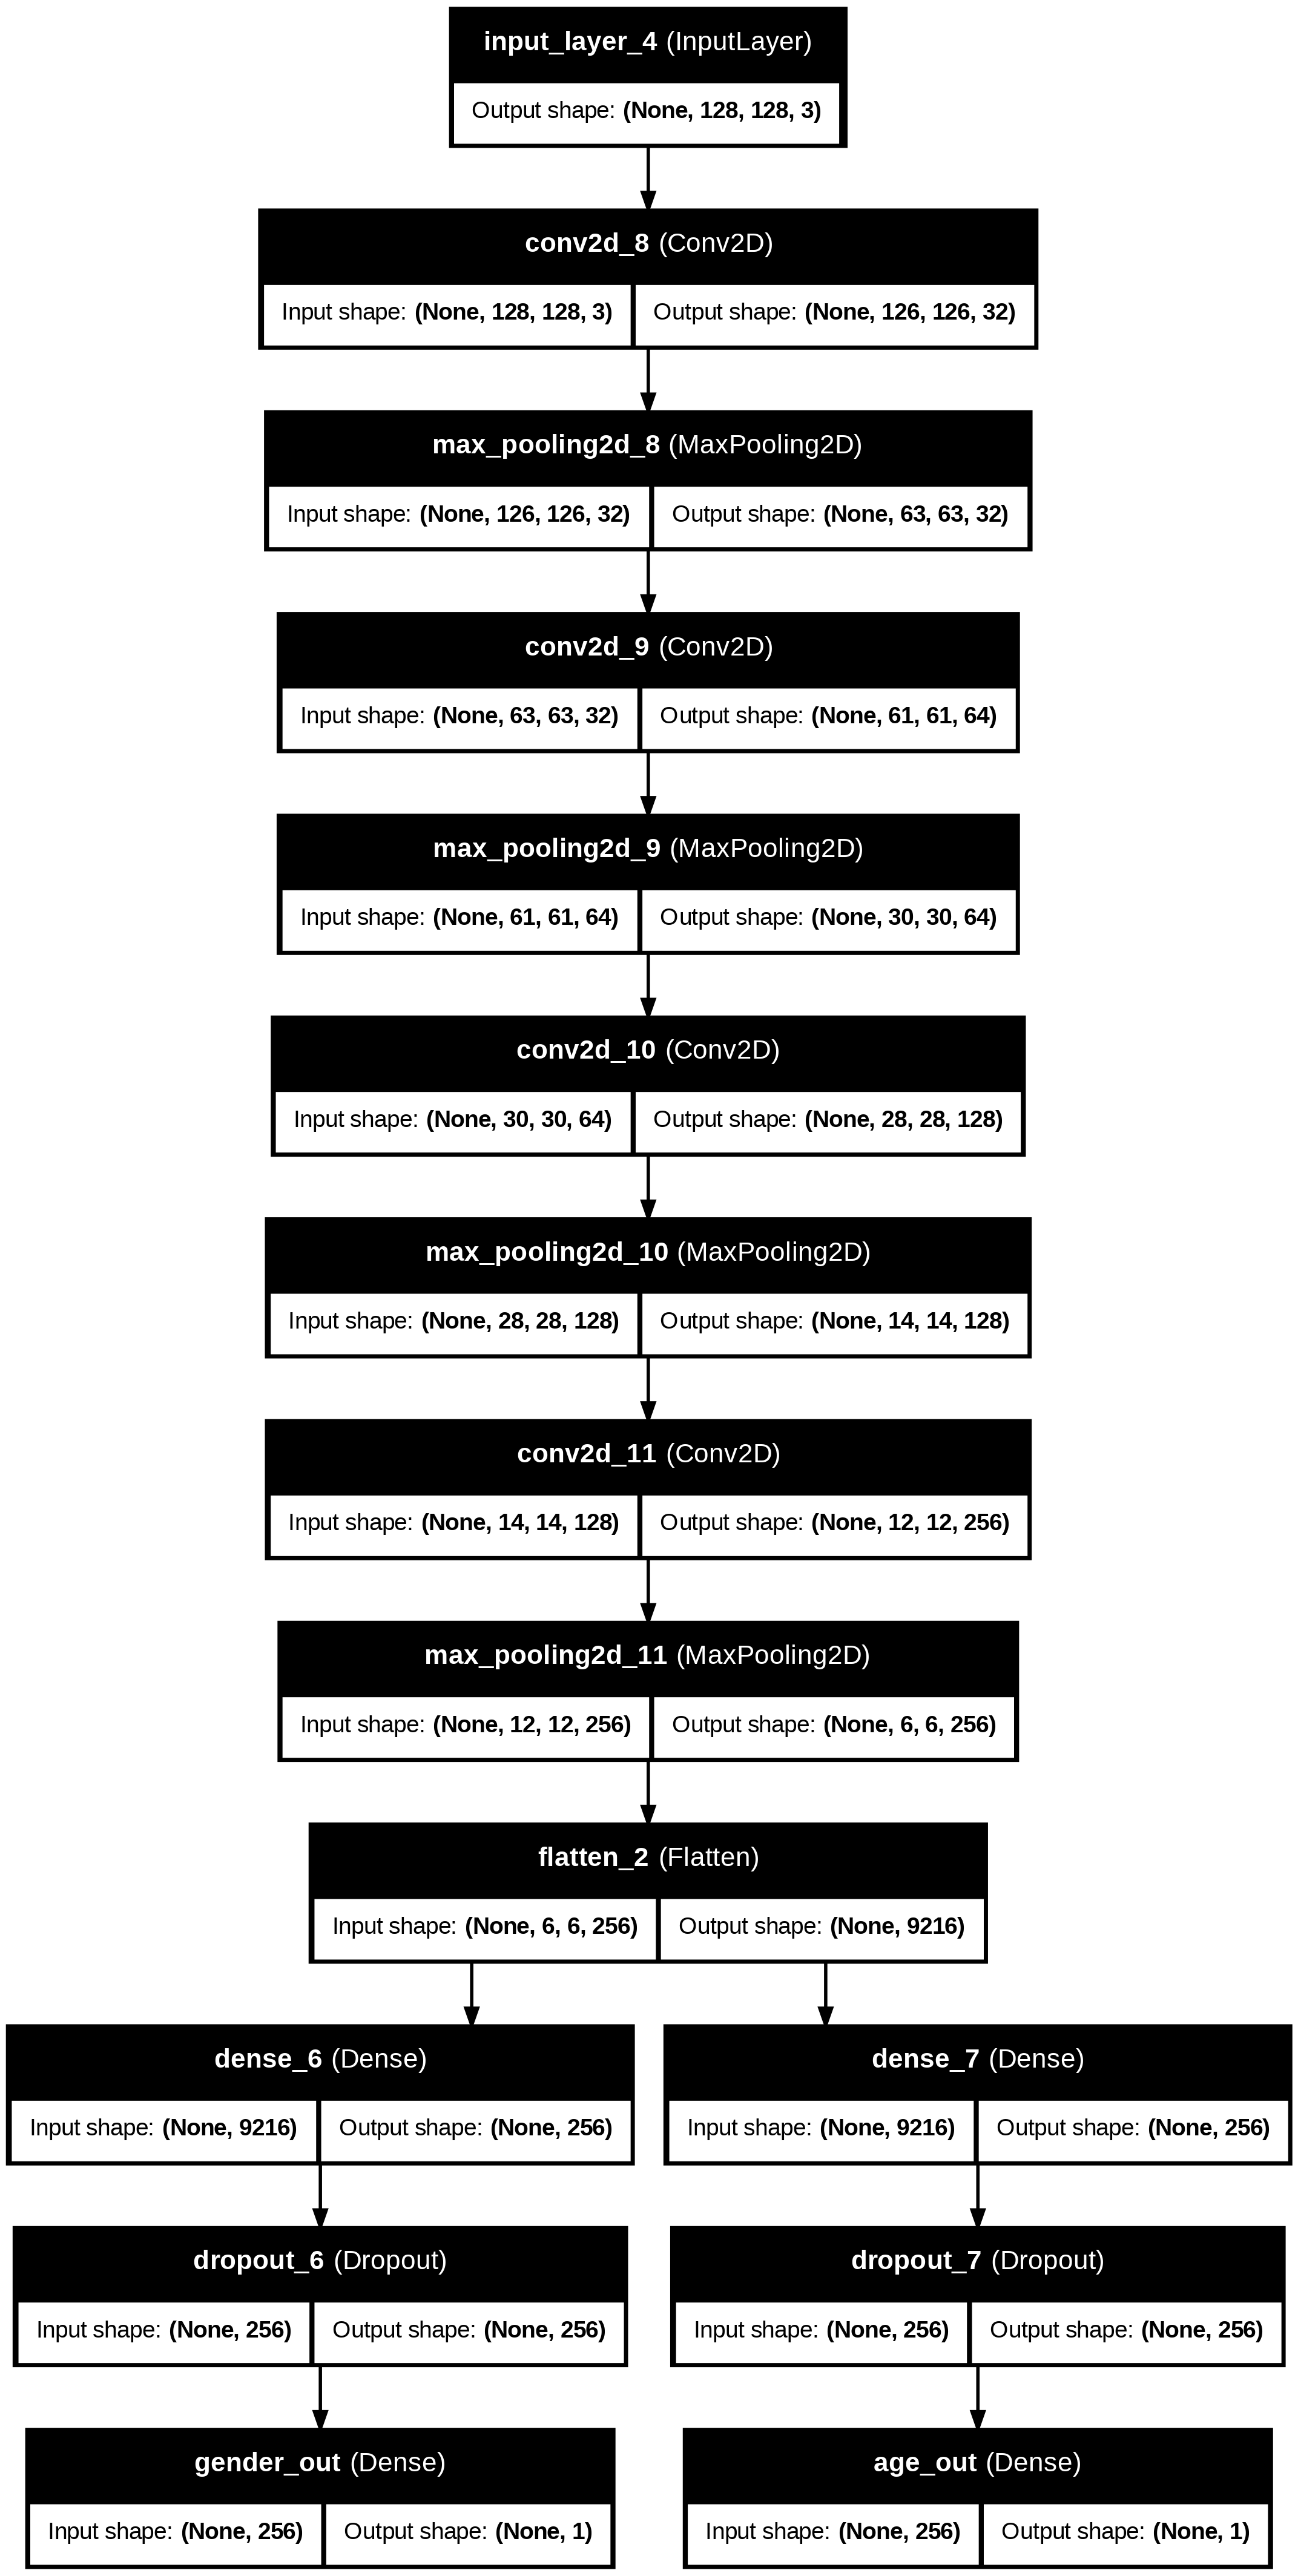

In [55]:
from tensorflow.keras.utils import plot_model

# Plot the model architecture and display the number of neurons
plot_model(model, show_shapes=True, show_layer_names=True)


### Plot the result : 

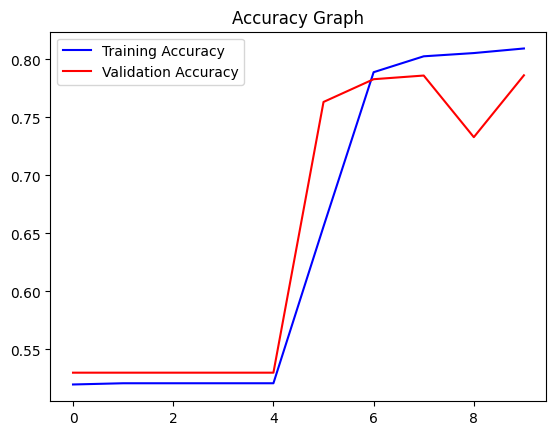

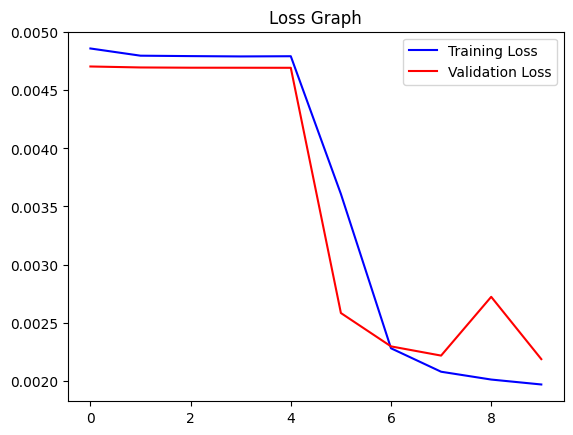

In [56]:
# Extract accuracy values for gender classification
acc = history.history.get('gender_out_accuracy', history.history.get('gender_out_acc'))
val_acc = history.history.get('val_gender_out_accuracy', history.history.get('val_gender_out_acc'))

# Plot accuracy graph
epochs = range(len(acc))
plt.plot(epochs, acc, 'b', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation Accuracy')
plt.title('Accuracy Graph')
plt.legend()
plt.figure()

# Extract loss values for gender classification
loss = history.history['gender_out_loss']
val_loss = history.history['val_gender_out_loss']

# Plot loss graph
plt.plot(epochs, loss, 'b', label='Training Loss')
plt.plot(epochs, val_loss, 'r', label='Validation Loss')
plt.title('Loss Graph')
plt.legend()
plt.show()
